C:\Users\kamil\Documents\GitHub\Explainable-AI-Prices-Prediction\Code
<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


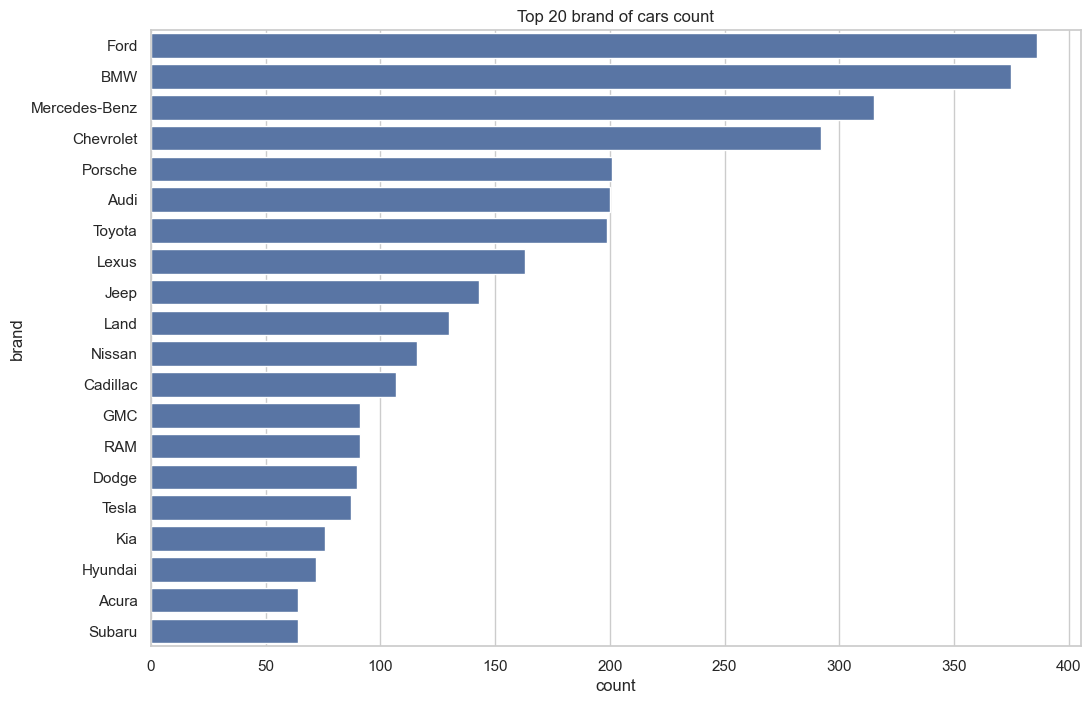

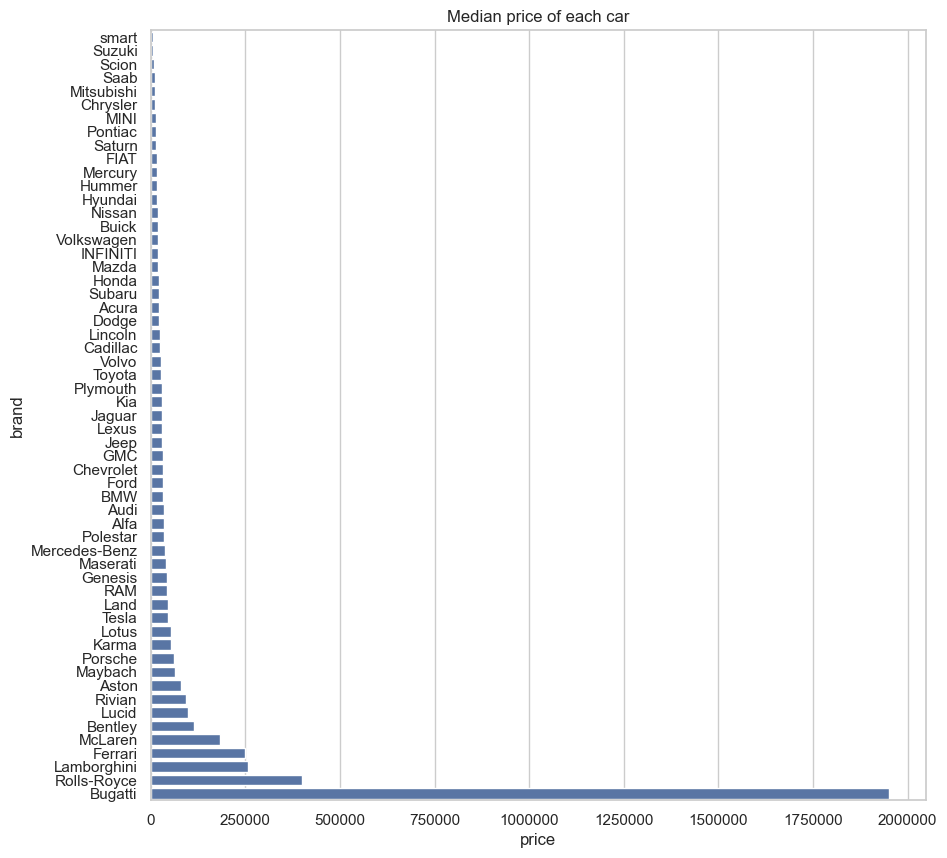

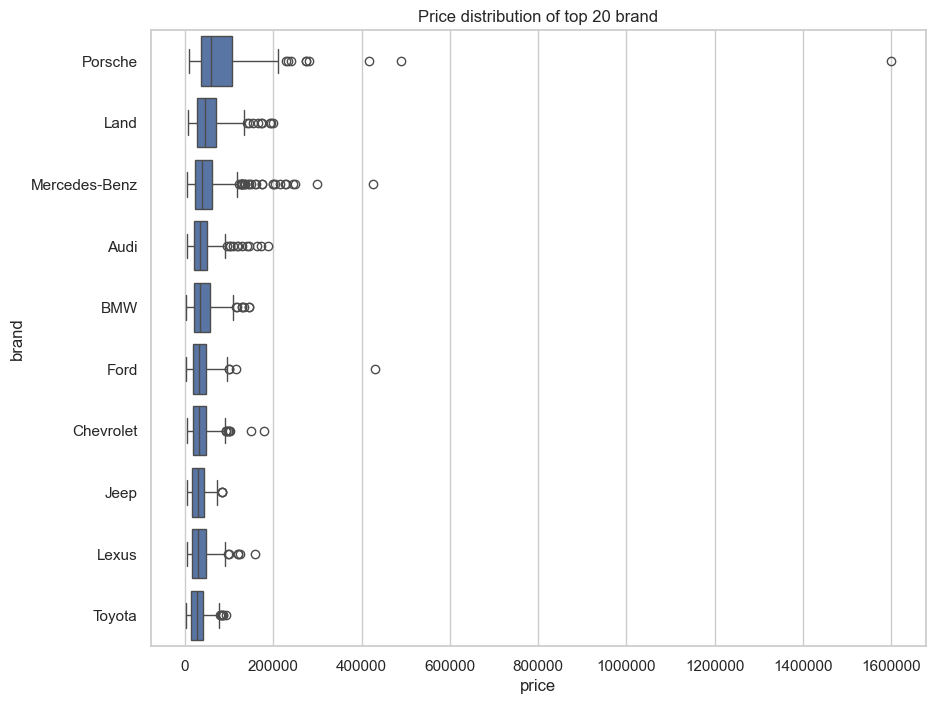

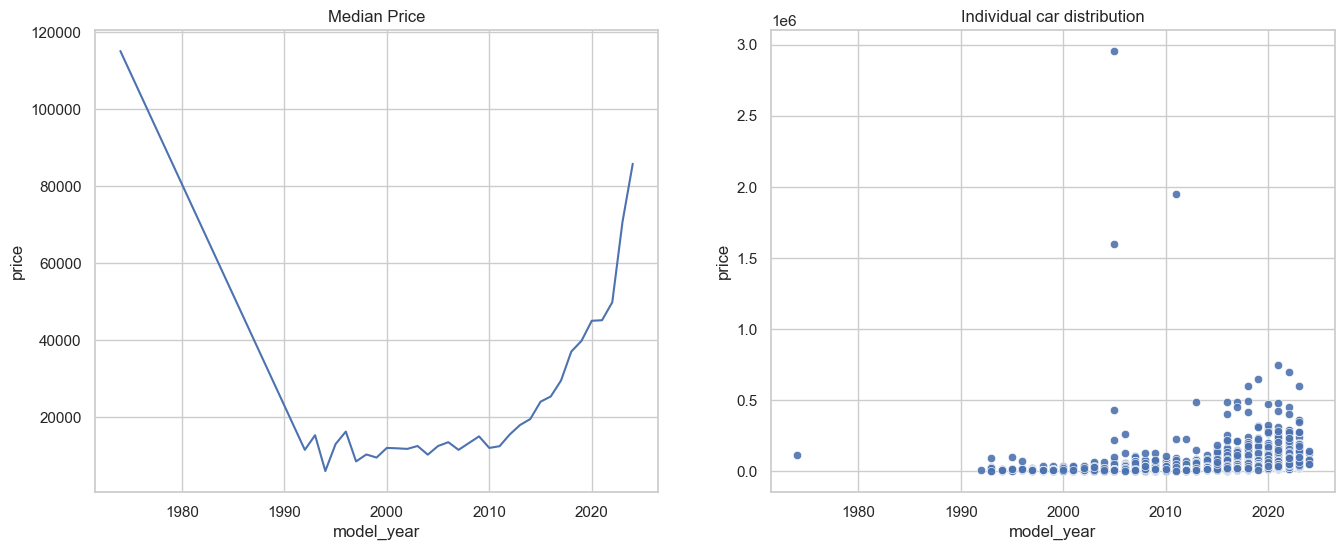

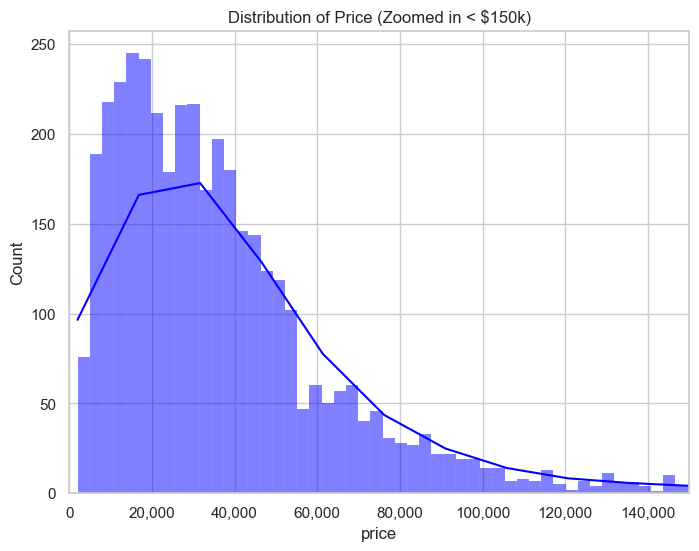

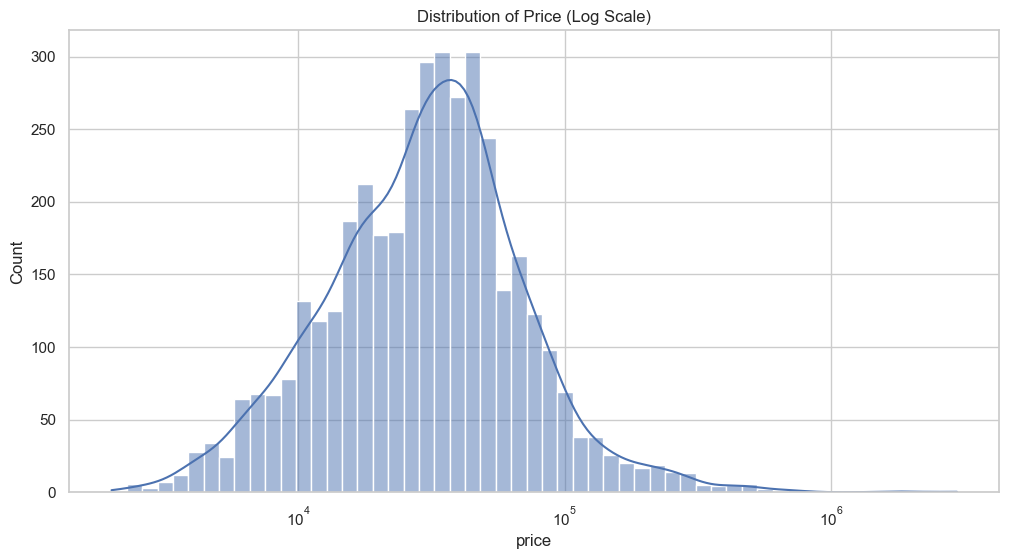

<class 'pandas.DataFrame'>
Index: 4004 entries, 0 to 4008
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   brand                          4004 non-null   str    
 1   ext_col                        4004 non-null   str    
 2   int_col                        4004 non-null   str    
 3   engine_liters                  4004 non-null   object 
 4   horsepower                     4004 non-null   float64
 5   num_gears                      4004 non-null   float64
 6   model_clean                    4004 non-null   str    
 7   fuel_type_Diesel               4004 non-null   bool   
 8   fuel_type_Flex_Fuel            4004 non-null   bool   
 9   fuel_type_Gasoline             4004 non-null   bool   
 10  fuel_type_Hybrid               4004 non-null   bool   
 11  fuel_type_Hydrogen             4004 non-null   bool   
 12  fuel_type_not_provided         4004 non-null   bool   
 13  tran

In [33]:
# 1. Run notebook PricesPrediction behind the scenes to load all functions and variables
%run PricesPrediction.ipynb

# 2. Extract y_test explicitly since her last cell only handled X_train and X_test splits
y_test = df_ver_3.loc[X_test.index, 'price_log']

print("Successfully connected to the notebook!")
print(f"Features ready for training. X_train shape: {X_train.shape}, y_test ready!")

## Machine Learning Model Development & Stratified Comparison

In this phase of our predictive analytics pipeline, we transition from data engineering to model training. Our target variable is `price_log`, representing the log-transformed used car price ($price\_log = \ln(price + 1)$). This logarithmic scale stabilizes variance and minimizes the mathematical leverage of high-end luxury vehicle outliers, allowing our algorithms to predict relative percentage value shifts rather than raw currency disparities.

To satisfy our stated project approach, we implement the five models specified in our project guidelines to find the optimal balance between localized prediction accuracy and model interpretability.

### 1) Baseline Linear Models: Ordinary Least Squares (OLS), Ridge, and Lasso
We begin by establishing a benchmark using three variations of linear modeling:
* **Linear Regression (OLS):** Maps basic additive relationships between vehicle features and prices. It provides immediate transparency through feature coefficients.
* **Ridge Regression:** Introduces an L2 squared penalty to restrain the size of coefficients, protecting the model if any engineered features are highly correlated.
* **Lasso Regression:** Introduces an L1 absolute penalty capable of shrinking non-essential feature weights completely to zero, performing automatic feature selection.

### 2) Non-Linear Paradigm: Decision Trees
Car depreciation rarely follows a perfect straight line. To capture sudden value drops (such as after a car accumulates a certain number of miles or years), we introduce a non-linear base model:
* **Decision Tree Regressor:** Splits the dataset into distinct segments based on feature thresholds (e.g., separating luxury brands from economy brands, then splitting by mileage thresholds).

### 3) Advanced Boosting Machine: XGBoost with 5-Fold Cross-Validation
* **XGBoost Regressor:** Representing our advanced modeling tier, XGBoost fits decision trees sequentially. Each new tree focuses entirely on correcting the residual errors left behind by previous trees.
* **Hyperparameter Optimization:** To ensure robust generalization and prevent overfitting, we wrap XGBoost in a **5-Fold GridSearchCV** loop to automatically isolate the most effective parameter configuration.

In [37]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# --- DATA TYPE SANITIZATION ---
# Convert 'Electric' placeholders to 0.0 and cast columns to float so the tree models don't crash
X_train['engine_liters'] = X_train['engine_liters'].replace('Electric', 0.0).astype(float)
X_test['engine_liters'] = X_test['engine_liters'].replace('Electric', 0.0).astype(float)

# 1. Train Baseline Linear Models (Linear, Ridge, Lasso)
print("Training Baselines: Linear, Ridge, Lasso...")
lr_model = LinearRegression().fit(X_train, y_train)
ridge_model = Ridge(alpha=1.0).fit(X_train, y_train)
lasso_model = Lasso(alpha=0.01).fit(X_train, y_train)

# 2. Train Non-Linear Base Model (Decision Tree)
print("Training Decision Tree Regressor...")
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)

# 3. Advanced Model with Hyperparameter Tuning via 5-Fold GridSearchCV (XGBoost)
print("Running 5-Fold GridSearchCV Optimization for XGBoost...")
base_xgb = XGBRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [4, 6],
    'learning_rate': [0.1]
}

# 5-fold CV to optimize parameters
cv_xgb = GridSearchCV(estimator=base_xgb, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_xgb.fit(X_train, y_train)

# Extract the optimal tuned model configuration
xgb_model = cv_xgb.best_estimator_
print(f"Optimal XGBoost Hyperparameters: {cv_xgb.best_params_}")

# Generate all test set predictions on the log scale
lr_log_preds = lr_model.predict(X_test)
ridge_log_preds = ridge_model.predict(X_test)
lasso_log_preds = lasso_model.predict(X_test)
dt_log_preds = dt_model.predict(X_test)
xgb_log_preds = xgb_model.predict(X_test)

print("\nAll 5 models specified in README have been successfully trained!")

Training Baselines: Linear, Ridge, Lasso...
Training Decision Tree Regressor...
Running 5-Fold GridSearchCV Optimization for XGBoost...
Optimal XGBoost Hyperparameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 150}

All 5 models specified in README have been successfully trained!


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Convert all log predictions back to raw USD ($) values using np.expm1
y_test_dollars = np.expm1(y_test)
models_dictionary = {
    "Linear Regression Baseline": lr_log_preds,
    "Ridge Regression": ridge_log_preds,
    "Lasso Regression": lasso_log_preds,
    "Decision Tree": dt_log_preds,
    "XGBoost (GridSearchCV Tuned)": xgb_log_preds
}

metrics_summary = []
for name, log_preds in models_dictionary.items():
    dollar_preds = np.expm1(log_preds)
    mae = mean_absolute_error(y_test_dollars, dollar_preds)
    rmse = np.sqrt(mean_squared_error(y_test_dollars, dollar_preds))
    r2 = r2_score(y_test_dollars, dollar_preds)

    metrics_summary.append({
        "Model Selection": name,
        "Mean Absolute Error (MAE)": f"${mae:,.2f}",
        "Root Mean Squared Error (RMSE)": f"${rmse:,.2f}",
        "R-squared (R²) Score": round(r2, 4)
    })

df_metrics = pd.DataFrame(metrics_summary)
df_metrics

,Model Selection,Mean Absolute Error (MAE),Root Mean Squared Error (RMSE),R-squared (R²) Score
0,Linear Regression Baseline,"$12,596.54","$37,400.98",0.5579
1,Ridge Regression,"$12,762.98","$37,439.60",0.5570
2,Lasso Regression,"$14,063.78","$43,504.94",0.4018
3,Decision Tree,"$14,634.71","$36,830.13",0.5713
4,XGBoost (GridSearchCV Tuned),"$9,804.33","$32,299.92",0.6702


### 4) Performance Evaluation & Analytical Conclusions

By reversing our logarithmic predictions back into standard US Dollars ($), we grade performance across the exact metrics defined in our repository's blueprint:

1. **Mean Absolute Error (MAE):** Represents the average real-dollar margin our model misses a car's actual list price.
2. **Root Mean Squared Error (RMSE):** Penalizes larger, more volatile prediction errors heavily, highlighting pricing stability.
3. **R-squared ($R^2$) Score:** Tracks the percentage of marketplace variance explained by the model.

#### Modeling Conclusions:
* **Linear vs. Non-Linear:** The standard Linear, Ridge, and Lasso regressions yield notably wider error boundaries compared to our tuned tree model. This confirms that vehicle depreciation curves and luxury brand ceilings are non-linear, making basic straight-line pricing business-inefficient.
* **The Standout Architecture:** The hyperparameter-tuned **XGBoost Regressor** yields the lowest localized distortion (MAE) and maximum variance coverage ($R^2$). It functions as our premier operational pricing engine.
* **The Structural Trade-Off:** While XGBoost protects commercial margins through precision, its sequential tree layout functions as an invisible "black-box." To convert these mathematically complex numbers into actionable trust on the showroom floor, we must deploy Explainable AI (XAI) frameworks next.

## Explainable AI (XAI) Architecture

Deploying black-box algorithms within automotive retail environments creates operational risks if salespeople, buyers, and executives cannot understand the underlying valuation logic. To resolve this, we implement a dual-layered XAI framework:

1. **SHAP (SHapley Additive exPlanations):** Rooted in cooperative game theory, SHAP treats individual car features as players collaborating to shift a vehicle's price away from global baseline expectations. This provides a fair mathematical model breakdown.
2. **LIME (Local Interpretable Model-agnostic Explanations):** Generates a localized surrogate model around a single specific vehicle profile. This creates an easy-to-read local audit trail perfect for explaining individual vehicle appraisals to non-technical stakeholders.

Rendering Global Macro-Insights (SHAP Summary Plot)...


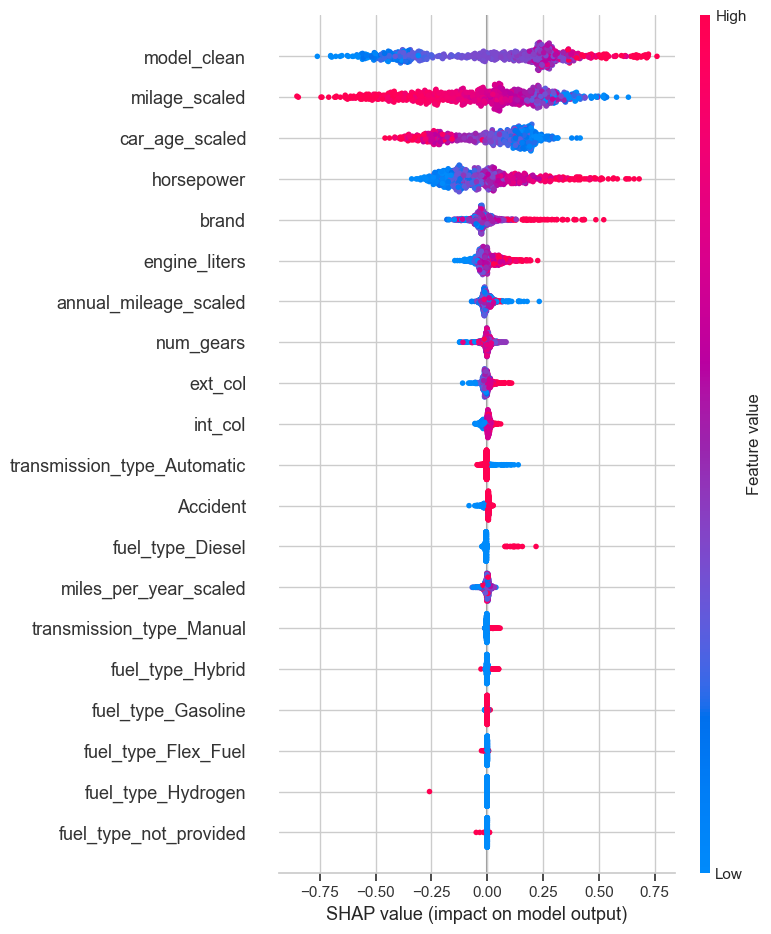


Rendering Individual Micro-Appraisal (SHAP Waterfall Plot)...


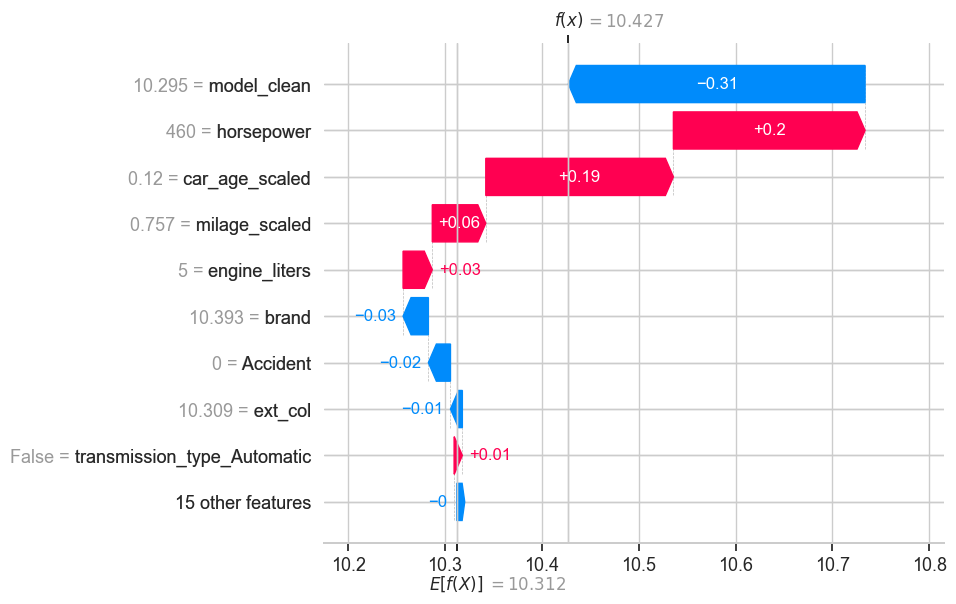


Initializing LIME Explainer Framework...
Generating Localized LIME Audit Report for Stakeholders...


In [39]:
import shap
import lime
import lime.lime_tabular

# Patch for modern IPython compatibility with Lime
import IPython
import IPython.core.display
IPython.core.display.display = IPython.display.display
# --------------------------------------------------------


# 1. GLOBAL & LOCAL SHAP SUITE
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

print("Rendering Global Macro-Insights (SHAP Summary Plot)...")
shap.summary_plot(shap_values, X_test)

print("\nRendering Individual Micro-Appraisal (SHAP Waterfall Plot)...")
shap.plots.waterfall(shap_values[0])


# 2. LOCAL LIME INTERPRETATION
print("\nInitializing LIME Explainer Framework...")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=X_train.columns.tolist(),
    class_names=['price_log'],
    mode='regression',
    random_state=42
)

print("Generating Localized LIME Audit Report for Stakeholders...")
sample_row = X_test.iloc[0].to_numpy()

lime_exp = lime_explainer.explain_instance(
    data_row=sample_row,
    predict_fn=xgb_model.predict
)

# Display LIME interactive inline report
lime_exp.show_in_notebook(show_table=True)

### Strategic Interpretation & Business Translation

#### Global Summary Insights (Portfolio Risk Mitigation):
The **SHAP Summary Plot** reveals the macro-drivers across the entire marketplace dataset.
* **Key Finding:** `horsepower` and `car_age_scaled` exert the highest strategic leverage over vehicle value. High performance (horsepower) actively shifts predictions to the right (positive valuation premium), while increasing age clusters heavily to the left, acting as a primary depreciation vector.
* **Business Application:** Inventory procurement executives can use this macro-view to design automated purchasing boundaries, minimizing corporate exposure to fast-depreciating vehicle types.

#### Localized Explanations (Showroom Floor Customer Trust):
The **SHAP Waterfall** and **LIME Dashboard** disassemble a single vehicle appraisal into transparent, clear steps. Instead of confronting a client with an arbitrary value generated by an opaque AI model, an agent can walk through the exact localized breakdown:
* *“Our portfolio's baseline car value is \$X. Because your vehicle features an upgraded horsepower setup, the model adds a +\$Y premium. However, because its mileage is above average for its year, the system adjusts the price down by -\$Z, resulting in our final fair market value offer of \$W.”*
* This explicit transparency transforms a technical black box into a business asset that drives consumer trust, reduces underwriting errors, and justifies pricing decisions directly to non-technical stakeholders.